## 1. Imports and Data

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [5]:

tickers = {
    "Information Technology": ["AAPL", "MSFT", "NVDA", "AVGO", "CRM"],  # High momentum, growth factor exposure
    "Financials": ["JPM", "BAC", "GS", "MS", "BLK", "WFC"],             # Value factor, rate sensitivity
    "Health Care": ["JNJ", "UNH", "LLY", "ABBV", "MRK", "PFE"],         # Defensive, quality factor
    "Consumer Discretionary": ["AMZN", "TSLA", "HD", "MCD", "NKE", "LOW"], # Cyclical, momentum variation
    "Industrials": ["CAT", "HON", "UNP", "RTX", "GE", "DE"],            # Classic value/quality mix
    "Communication Services": ["GOOGL", "META", "DIS", "NFLX", "T"],    # Growth vs. value spread
    "Consumer Staples": ["PG", "KO", "PEP", "WMT", "COST", "CL"],       # Low vol, defensive
    "Energy": ["XOM", "CVX", "COP", "SLB", "EOG"],                      # Value, commodity beta
    "Utilities": ["NEE", "DUK", "SO", "AEP", "EXC"],                    # Low vol, yield factor
    "Real Estate": ["PLD", "AMT", "EQIX", "SPG", "PSA"],                # Yield, rate sensitivity
    "Materials": ["LIN", "APD", "NEM", "FCX", "SHW"],                   # Cyclical, commodity exposure
}

all_tickers = [ticker for sector in tickers.values() for ticker in sector]



In [6]:
start_date = "2010-01-01"
end_date = "2025-01-01"

data = yf.download(
    [ticker for sector in tickers.values() for ticker in sector],
    start=start_date,
    end=end_date,
    interval = "1mo"
)["Close"]

# Compute returns
returns = np.log(data).diff().dropna()

# Data Quality Checks
# 1. Are there any NaNs?
print(returns.isna().sum().sum())

# 2. Are they at the start?
print(returns.iloc[0].isna().sum())

# 3. Flag outliers (returns > 50% or < -50%)
outliers = (returns > 0.5) | (returns < -0.5)
outliers_df = returns[outliers].stack(level = 'Ticker')
print(outliers_df)

data.to_csv("data/prices.csv")
returns.to_csv("data/returns.csv")

C:\Users\godwi\AppData\Local\Temp\ipykernel_28084\1760627635.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  60 of 60 completed


0
0
Date        Ticker
2013-05-01  TSLA      0.593717
2016-02-01  FCX       0.506031
2020-03-01  EOG      -0.565959
            SLB      -0.682553
            SPG      -0.792845
2020-08-01  TSLA      0.554719
2022-04-01  NFLX     -0.676915
dtype: float64


In [7]:
# Compare to benchmark
spy_row = yf.download(
    "SPY",
    start=start_date,
    end=end_date,
    interval = "1mo"
)

spy_prices = spy_row["Close"]["SPY"]

spy_returns = np.log(spy_prices).diff().dropna()
spy_returns = spy_returns.reindex(returns.index)
spy_returns.to_csv("data/spy_returns.csv")

# Check shape
print(returns.shape)        # (T, N)
print(spy_returns.shape)    # (T,)
# Confirm all share the same index
assert returns.index.equals(spy_returns.index)

assert len(returns) == len(spy_returns), \
    "returns and spy_returns have different lengths"


C:\Users\godwi\AppData\Local\Temp\ipykernel_28084\2373587483.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_row = yf.download(


[*********************100%***********************]  1 of 1 completed


(143, 60)
(143,)


## 2. Raw Signals

In [8]:
# Pull Fundamental Data
# Market Cap
shares_dict = {}
for ticker in all_tickers:
    try:
        info = yf.Ticker(ticker).info
        shares = info.get('sharesOutstanding', None)
        shares_dict[ticker] = shares
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        shares_dict[ticker] = None

shares_series = pd.Series(shares_dict)
missing = shares_series[shares_series.isna()]
print(missing) # None
market_cap = data.multiply(shares_series, axis=1)
market_cap.to_csv("data/market_cap.csv")
log_market_cap = np.log(market_cap)
log_market_cap.to_csv("data/log_market_cap.csv")

print(log_market_cap.shape) # 120 Months x 60 stocks
print(log_market_cap.head())

Series([], dtype: int64)
(180, 60)
                 AAPL  ABBV        AEP        AMT       AMZN        APD  \
Date                                                                      
2010-01-01  25.159348   NaN  23.028371  23.375254  24.934689  23.064724   
2010-02-01  25.222694   NaN  22.998194  23.380188  24.877169  22.962518   
2010-03-01  25.361126   NaN  23.026977  23.379016  25.014063  23.037906   
2010-04-01  25.466405   NaN  23.030481  23.335853  25.023811  23.082078   
2010-05-01  25.450149   NaN  22.959821  23.328968  24.935087  22.976109   

                 AVGO        BAC        BLK        CAT  ...        SLB  \
Date                                                    ...              
2010-01-01  22.483284  25.137923  23.804409  23.500736  ...  24.882613   
2010-02-01  22.526635  25.230955  23.827433  23.595615  ...  24.844716   
2010-03-01  22.651311  25.299948  23.822668  23.692438  ...  24.885861   
2010-04-01  22.648877  25.299434  23.658849  23.772517  ...  25.00403

In [9]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
# Compute Raw Signal Values
# 1. Market Beta
# Run OLS over past 36 months
beta_window = 36
monthly_index = returns.index
beta_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

assert returns.index.equals(spy_returns.index), \
    "returns and spy_returns have different indices — align them first"

for i, date in enumerate(monthly_index):
    if i < beta_window:
        continue  # Not enough data for the first few months


    window_returns = returns.iloc[i-beta_window:i]
    window_spy = spy_returns.iloc[i-beta_window:i]
    
    valid_mask = window_spy.notna() 
    if valid_mask.sum() < 24:
        continue

    spy_window_clean = window_spy[valid_mask] 

    for ticker in all_tickers:
        y = window_returns.loc[window_spy.index, ticker]

        combined_valid = valid_mask & y.notna()

        if combined_valid.sum() < 24: 
            continue

        y_clean = y[combined_valid].values
        spy_clean = window_spy[combined_valid].values
        X_clean = add_constant(spy_clean, has_constant="add")  # Recreate X with cleaned spy data

        try:
            model = OLS(y_clean, X_clean).fit()
            beta_panel.loc[date, ticker] = model.params[1]  # Store the beta coefficient

        except Exception:
            pass

beta_panel.to_csv("data/signal_beta_raw.csv")


    

In [10]:
# Sanity check
print((beta_panel < -1).sum().sum())
print((beta_panel > 3).sum().sum()) 
beta_panel.describe()

0
10


,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,...,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000
mean,1.209817,0.997646,1.680791,0.976279,1.234584,1.125008,1.450089,1.319078,1.382783,1.402046,...,0.981958,0.642064,0.563060,1.194146,0.372516,0.889348,0.904858,0.278364,2.168974,1.172563
std,0.126088,0.192602,0.516005,0.233433,0.180872,0.081986,0.174440,0.130643,0.185242,0.197813,...,0.185710,0.360573,0.261462,0.673906,0.296591,0.211928,0.177427,0.275050,0.480583,0.146815
min,0.857290,0.723167,0.889585,0.347595,0.938771,0.908345,1.129594,1.007944,0.968409,1.069550,...,0.720755,0.005013,0.143121,0.270694,-0.111242,0.431363,0.667355,-0.395557,1.354618,0.952004
25%,1.164762,0.837106,1.281467,0.874298,1.089722,1.058655,1.261481,1.222511,1.251678,1.208763,...,0.855900,0.256175,0.342740,0.523968,0.130957,0.743161,0.758977,0.169747,1.749977,1.042354
50%,1.204458,0.983619,1.403222,0.977349,1.214381,1.137255,1.528630,1.313538,1.438045,1.428782,...,0.945992,0.811603,0.554156,1.419556,0.348461,0.955597,0.855405,0.370040,2.118408,1.140322
75%,1.281389,1.117180,2.234363,1.166202,1.348517,1.179550,1.580497,1.417255,1.529231,1.574080,...,1.066045,0.954311,0.652687,1.872237,0.510098,1.081159,1.049470,0.443193,2.477991,1.270549
max,1.493848,1.435642,2.678085,1.353740,1.609268,1.363188,1.736352,1.619205,1.663066,1.676580,...,1.425441,1.133306,1.104264,2.220809,0.965903,1.175877,1.329904,0.856172,3.190350,1.470349


In [11]:
"""
fig, axes = plt.subplots(10, 6, figsize=(18, 28))
axes = axes.flatten()

for i, ticker in enumerate(beta_panel.columns):
    ax = axes[i]
    beta_panel[ticker].plot(ax=ax, linewidth=1.5)
    mean_beta = beta_panel[ticker].mean()
    ax.axhline(mean_beta, color="red", ls="--", linewidth=1, label="Mean")
    ax.set_title(f"{ticker}, Mean Beta = {mean_beta:.2f}")
    ax.set_ylabel("Beta")

for j in range(len(beta_panel.columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Rolling 36-Month Beta vs SPY", y=1.002)
fig.tight_layout()
plt.savefig("outputs/beta_panel.png")
plt.show()
"""

'\nfig, axes = plt.subplots(10, 6, figsize=(18, 28))\naxes = axes.flatten()\n\nfor i, ticker in enumerate(beta_panel.columns):\n    ax = axes[i]\n    beta_panel[ticker].plot(ax=ax, linewidth=1.5)\n    mean_beta = beta_panel[ticker].mean()\n    ax.axhline(mean_beta, color="red", ls="--", linewidth=1, label="Mean")\n    ax.set_title(f"{ticker}, Mean Beta = {mean_beta:.2f}")\n    ax.set_ylabel("Beta")\n\nfor j in range(len(beta_panel.columns), len(axes)):\n    fig.delaxes(axes[j])\n\nfig.suptitle("Rolling 36-Month Beta vs SPY", y=1.002)\nfig.tight_layout()\nplt.savefig("outputs/beta_panel.png")\nplt.show()\n'

In [12]:
# 2. Momentum
mom_start = 12 # 12 months lookback
mom_end = 1 # exclude most recent month - noisy
momentum_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

for i, date in enumerate(monthly_index):
    if i < mom_start:
        continue  # Not enough data for the first few months

    window = returns.iloc[i-mom_start:i-mom_end] 
    compounded = (1 + window).prod(axis = 0, skipna = False) - 1
    momentum_panel.loc[date] = compounded

momentum_panel.to_csv("data/signal_momentum_raw.csv")
print(momentum_panel)

                AAPL      MSFT      NVDA      AVGO       CRM       JPM  \
Date                                                                     
2013-02-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-03-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-04-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-05-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-06-01       NaN       NaN       NaN       NaN       NaN       NaN   
...              ...       ...       ...       ...       ...       ...   
2024-08-01  0.051980  0.314988  1.367512  0.725579  0.082536  0.285725   
2024-09-01  0.159496  0.258990  1.123252  0.687499  0.107280  0.452157   
2024-10-01  0.315451  0.301165  1.478508  0.911244  0.188168  0.553817   
2024-11-01  0.343209  0.257860  1.694839  0.985215  0.294632  0.518054   
2024-12-01  0.176473  0.064545  1.581452  0.789112  0.123137  0.421125   

                 BAC        GS       

In [13]:
# 3. Size
size_panel = log_market_cap.copy()
size_panel = size_panel.reindex(index=monthly_index)
size_panel = size_panel.reindex(columns=all_tickers)

assert size_panel.index.equals(monthly_index), \
    "Index mismatch between size panel and returns index"

assert size_panel.columns.tolist() == all_tickers, \
    "Column mismatch between size panel and returns columns"

size_panel.to_csv("data/signal_size_raw.csv")

In [14]:
# 4. Low Volatility
vol_window = 12
low_vol_panel = -returns.rolling(window = vol_window, min_periods = 10).std() # Negative for low vol = high score
low_vol_panel = low_vol_panel.reindex(index=monthly_index)
low_vol_panel = low_vol_panel.reindex(columns=all_tickers)
low_vol_panel.to_csv("data/signal_lowvol_raw.csv")

In [15]:
# 5. Long-term Reversal
ltr_start = 36
ltr_end = 12
ltr_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

for i, date in enumerate(monthly_index):
    if i < ltr_start:
        continue  
    
    window = returns.iloc[i-ltr_start:i-ltr_end] 
    compounded = (1 + window).prod(axis = 0, skipna = False) - 1
    ltr_panel.loc[date] = -compounded 

ltr_panel.to_csv("data/signal_ltr_raw.csv")

In [16]:
'''
dates = np.load("data/dates.npy", allow_pickle=True) 
tickers = np.load("data/tickers.npy", allow_pickle=True)  
factors = np.load("data/factors.npy", allow_pickle=True) 


data = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)
returns = pd.read_csv("data/returns.csv", index_col=0, parse_dates=True).reindex(dates)
spy_returns = pd.read_csv("data/spy_returns.csv", index_col=0, parse_dates=True).reindex(dates)
mktcap_panel = pd.read_csv("data/market_cap.csv", index_col=0, parse_dates=True).reindex(dates)
beta_panel = pd.read_csv("data/signal_beta_raw.csv", index_col=0, parse_dates=True)
momentum_panel = pd.read_csv("data/signal_momentum_raw.csv", index_col=0, parse_dates=True)
size_panel = pd.read_csv("data/signal_size_raw.csv", index_col=0, parse_dates=True)
low_vol_panel = pd.read_csv("data/signal_lowvol_raw.csv", index_col=0, parse_dates=True)
ltr_panel = pd.read_csv("data/signal_ltr_raw.csv", index_col=0, parse_dates=True)
'''



print(beta_panel.shape)
print(momentum_panel.shape)
print(size_panel.shape)
print(low_vol_panel.shape)
print(ltr_panel.shape)

(143, 60)
(143, 60)
(143, 60)
(143, 60)
(143, 60)


In [17]:
# Winsorise, Z-score normalisation and Burn-in
# Set values < 1%ile to 1%ile, > 99%ile to 99%ile, across all stocks, at each time t - hence 'cross sectional'
def winsorise(signal_panel: pd.DataFrame, lower = 0.01, upper = 0.99) -> pd.DataFrame:
    def winsorise_row(row):
        lower_bound = row.quantile(lower)
        upper_bound = row.quantile(upper)
        return row.clip(lower=lower_bound, upper=upper_bound)
    
    return signal_panel.apply(winsorise_row, axis=1)

def normalise(signal_panel: pd.DataFrame) -> pd.DataFrame:
    def normalise_row(row):
        mu = row.mean()
        sig = row.std()
        if sig == 0:
            return row - mu
        return (row - mu) / sig

    return signal_panel.apply(normalise_row, axis=1)

def trim_burn_in(signal_panel: pd.DataFrame, burn_in_periods = 36) -> pd.DataFrame:
    return signal_panel.iloc[burn_in_periods:]



In [18]:
signals_raw = {
    "beta": beta_panel,
    "momentum": momentum_panel,
    "size": size_panel,
    "low_vol": low_vol_panel,
    "ltr": ltr_panel
}

signals_processed = {
    name: trim_burn_in(winsorise(normalise(panel))) for name, panel in signals_raw.items() 
}

np.save("data/signals_raw.npy", signals_raw)
np.save("data/signals_processed.npy", signals_processed)

In [19]:
# Trim signals due to burn-in
for signal in signals_processed.values():
    print(signal.isna().sum().sum())
    print(signal.shape)

# No NaNs


0
(107, 60)
0
(107, 60)
0
(107, 60)
0
(107, 60)
0
(107, 60)


## 3. Orthogonalise and weights via Information Coefficient

In [20]:
def residualise(target: pd.DataFrame, controls):
    if isinstance(controls, (pd.DataFrame, pd.Series)):
        controls = [controls]
    elif isinstance(controls, tuple):
        controls = list(controls)
    elif not isinstance(controls, list):
        raise TypeError("controls must be a DataFrame, Series, list, or tuple")

    controls = [
        ctrl.reindex(index=target.index, columns=target.columns)
        if isinstance(ctrl, pd.DataFrame)
        else ctrl.reindex(index=target.index)
        for ctrl in controls
    ]

    residuals = pd.DataFrame(index=target.index, columns=target.columns, dtype=float)

    for t in target.index:
        y = target.loc[t]
        X = pd.concat(
            [ctrl.loc[t].rename(f"ctrl_{i}") for i, ctrl in enumerate(controls)],
            axis=1,
        )

        common_idx = y.index.intersection(X.index)
        y = y.reindex(common_idx)
        X = X.reindex(common_idx)

        valid = y.notna() & X.notna().all(axis=1)
        if valid.sum() < 2:
            continue

        y_clean = y.loc[valid]
        X_clean = X.loc[valid]
        X_clean = add_constant(X_clean, has_constant="add")

        try:
            model = OLS(y_clean, X_clean).fit()
            residuals.loc[t, X_clean.index] = model.resid
        except Exception:
            continue

    return residuals

# 1. Size orthogonal to beta
size_clean = residualise(signals_processed["size"], signals_processed["beta"])

# 2. low vol orthogonal to beta + size
lowvol_clean = residualise(
    signals_processed["low_vol"],
    [signals_processed["beta"], size_clean],
)

# 3. momentum orthogonal to beta + size + low vol
momentum_clean = residualise(
    signals_processed["momentum"],
    [signals_processed["beta"], size_clean, lowvol_clean],
)

# 4. ltr orthogonal to beta + size + low vol + momentum
ltr_clean = residualise(
    signals_processed["ltr"],
    [signals_processed["beta"], size_clean, lowvol_clean, momentum_clean],
)

signals_cleaned = {
    "beta": signals_processed["beta"],
    "momentum": momentum_clean,
    "size": size_clean,
    "low_vol": lowvol_clean,
    "ltr": ltr_clean
}
    
np.save("data/signals_cleaned.npy", signals_cleaned)

dates = signals_cleaned["beta"].index
factors = list(signals_cleaned.keys())




In [21]:
returns = returns.reindex(dates)

def compute_ic(name: str, signal: pd.DataFrame, returns: pd.DataFrame):
    returns = returns.shift(-1) # align r_{t+1}
    ic_series = pd.DataFrame(index = signal.index, columns = [name])
    
    for t in signal.index:
        x = signal.loc[t]
        r = returns.loc[t]

        valid = x.notna() & r.notna()

        ic = x[valid].corr(r[valid])
        ic_series.loc[t] = ic

    return ic_series



In [22]:
ic_df = pd.DataFrame(index = dates)
for name, signal in signals_processed.items():
    ic_df = pd.concat([ic_df, compute_ic(name, signal, returns)], axis = 1)
ic_df.dropna(inplace = True)
weights_rolling = normalise(ic_df).rolling(window = 24).mean().dropna()
weights_rolling

,beta,momentum,size,low_vol,ltr
Date,,,,,
2018-01-01,0.501219,0.225619,-0.006553,-0.418342,-0.301944
2018-02-01,0.413331,0.200899,-0.019318,-0.315254,-0.279658
2018-03-01,0.342318,0.234179,0.065636,-0.287410,-0.354723
2018-04-01,0.405634,0.221392,0.072497,-0.362086,-0.337437
2018-05-01,0.431413,0.163568,0.118566,-0.381934,-0.331614
...,...,...,...,...,...
2024-07-01,0.069658,0.208258,0.091536,-0.269201,-0.100251
2024-08-01,0.154106,0.120804,0.072319,-0.298814,-0.048414
2024-09-01,0.152540,0.147369,0.149409,-0.303672,-0.145646


In [23]:
t_eval = weights_rolling.index
np.save('data/t_eval.npy', t_eval)

for name, signal in signals_cleaned.items():
    signals_cleaned[name] = signal.reindex(t_eval)

signal_matrix = np.stack(
    [
        signals_cleaned["beta"].values,   
        signals_cleaned["momentum"].values,     
        signals_cleaned["size"].values,    
        signals_cleaned["low_vol"].values,   
        signals_cleaned["ltr"].values  
    ],
    axis=2   # stack along the 3rd dimension
)

signal_matrix.shape

(83, 60, 5)

In [24]:
weights = weights_rolling.to_numpy()
scores = np.sum(signal_matrix * weights[:, None, :], axis = 2)
scores = pd.DataFrame(
    scores, 
    index = t_eval, 
    columns = all_tickers
)

scores.to_csv('data/factor_scores.csv')
scores

,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.285924,0.176170,2.691083,0.573613,0.510392,0.242664,0.534564,0.271445,0.434540,0.342693,...,-0.220225,0.047586,-0.026582,-0.495423,-0.569212,-0.144772,-0.188472,-0.083798,1.734558,0.390573
2018-02-01,-0.061881,0.052744,2.329458,0.287268,0.289686,0.112970,0.311693,0.076597,0.227630,0.269786,...,-0.083767,0.027838,0.277437,-0.417882,-0.624995,-0.032055,-0.141562,-0.034822,1.135665,0.279118
2018-03-01,-0.182815,0.223865,2.303349,0.096067,0.047078,0.158996,0.428379,-0.000035,0.147826,0.137342,...,0.007629,-0.057475,0.385634,-0.427716,-0.547284,-0.116625,-0.269943,-0.139705,0.611090,0.110283
2018-04-01,-0.007612,0.266283,2.423315,0.083315,0.025184,0.137524,0.427476,-0.044002,0.126796,0.115312,...,-0.166178,-0.061977,0.195809,-0.523359,-0.725784,-0.156342,-0.405465,-0.148275,0.922213,0.069119
2018-05-01,0.208287,0.157566,2.088080,0.262880,-0.043337,0.024200,0.408086,-0.149404,0.041803,0.029886,...,-0.123085,-0.070472,0.163488,-0.617544,-0.835746,-0.223178,-0.524051,-0.318605,1.118532,0.084576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-01,-0.063842,0.009303,0.999391,0.512933,0.079336,-0.008625,-0.027162,0.006557,0.140746,-0.173745,...,0.114836,0.065009,-0.221267,-0.106885,-0.103534,-0.225419,-0.366204,0.346108,0.192533,0.081354
2024-08-01,0.001408,0.019113,1.031300,0.471137,0.297287,-0.155147,-0.152869,-0.122960,0.161193,-0.006708,...,0.352126,0.222917,-0.094173,-0.134776,0.134956,-0.269966,-0.266403,0.384152,0.217711,0.193071
2024-09-01,0.130805,0.172721,1.284392,0.647153,0.231767,0.071559,-0.138593,-0.020627,0.145017,-0.097425,...,0.271769,0.091409,-0.212608,-0.253765,0.016573,-0.268337,-0.350317,0.304740,0.187224,0.157842


In [25]:
"""
rank_df = scores.rank(axis=1, ascending=False)
rank_df
"""

'\nrank_df = scores.rank(axis=1, ascending=False)\nrank_df\n'

## 4. Evaluate Portfolio

In [26]:
# Long top 20%, Short bottom 20%
def long_short_weights(scores, quantile=0.2):

    w = pd.DataFrame(
        0.0,
        index = scores.index,
        columns = scores.columns
    )

    for time, row in scores.iterrows():
        n = int(np.floor(len(row) * quantile))

        ranked = row.sort_values(ascending = False)
        longs = ranked.index[:n]
        shorts = ranked.index[-n:]

        w.loc[time, longs] = 0.5 / n
        w.loc[time, shorts] = -0.5 / n

    return w



In [27]:
returns_eval = returns.shift(-1).reindex(t_eval)
returns_eval

Ticker,AAPL,ABBV,AEP,AMT,AMZN,APD,AVGO,BAC,BLK,CAT,...,SLB,SO,SPG,T,TSLA,UNH,UNP,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.061892,0.038810,-0.047642,-0.058338,0.041554,-0.046065,-0.006350,0.003120,-0.022264,-0.046733,...,-0.114188,-0.046509,-0.062252,-0.013730,-0.032267,-0.045889,-0.024646,-0.118829,-0.169163,-0.142044
2018-02-01,-0.055735,-0.201938,0.054542,0.042231,-0.044003,-0.011006,-0.044852,-0.067992,-0.014132,-0.048021,...,-0.006156,0.049585,0.017971,-0.018069,-0.253920,-0.055267,0.036861,-0.102443,-0.011621,-0.004858
2018-03-01,-0.015134,0.019875,0.020063,-0.063777,0.078880,0.027270,-0.012247,0.001408,-0.032744,-0.020704,...,0.056712,0.032169,0.012810,-0.086374,0.099255,0.102855,-0.005969,-0.008623,0.000195,0.041224
2018-04-01,0.122893,0.034757,-0.029438,0.019884,0.039739,-0.005437,0.094153,-0.029853,0.024117,0.056000,...,0.001604,-0.026809,0.024515,0.007065,-0.031698,0.021386,0.066090,0.038325,-0.069268,0.043909
2018-05-01,-0.005614,-0.065684,0.028213,0.041062,0.042164,-0.035824,-0.038128,-0.025629,-0.068140,-0.113062,...,-0.024172,0.044771,0.073057,-0.006519,0.186043,0.015734,-0.002513,0.034003,0.043267,0.028260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-01,0.030684,0.066755,0.021775,0.016470,-0.046413,0.062176,0.013231,0.010856,0.028467,0.032259,...,-0.093262,0.033902,0.086778,0.048106,-0.080549,0.024076,0.037234,-0.014770,0.117913,-0.005496
2024-08-01,0.018473,0.005942,0.031888,0.037234,0.042931,0.065547,0.057752,-0.026609,0.051542,0.093803,...,-0.047484,0.051096,0.009930,0.100323,0.200441,-0.009397,-0.032942,-0.026840,0.047416,0.001895
2024-09-01,-0.030902,0.031845,-0.038246,-0.085324,0.000376,0.042060,-0.012669,0.059026,0.038557,-0.038894,...,-0.039327,0.009381,0.013132,0.024249,-0.046071,-0.031585,-0.060242,0.139092,0.014751,-0.003761


In [28]:
weights = long_short_weights(scores)
portfolio_returns = (weights * returns_eval).sum(axis = 1)
portfolio = (1 + portfolio_returns).cumprod()

spy_eval = spy_returns.reindex(t_eval)
benchmark = (1 + spy_eval).cumprod()

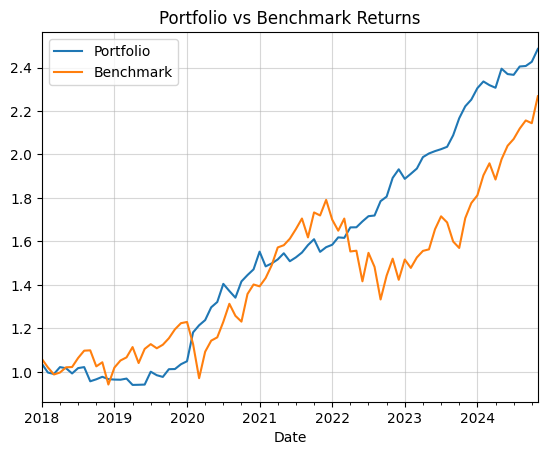

In [29]:
fig, ax = plt.subplots()

portfolio.plot(ax = ax, label = 'Portfolio')
benchmark.plot(ax = ax, label = 'Benchmark')
ax.set_title('Portfolio vs Benchmark Returns')
ax.grid(alpha = 0.5)
ax.legend()
plt.savefig("outputs/Portfolio_vs_Benchmark.png")

## 5. Analytics

In [30]:
def analyse_portfolio(portfolio_returns):
    mean = portfolio_returns.mean()
    std = portfolio_returns.std()
    sharpe = np.sqrt(12) * mean / std

    portfolio = (1 + portfolio_returns).cumprod()
    total_return = portfolio.iloc[-1] - 1
    annual_return = (1 + total_return) ** (12 / len(portfolio)) - 1
    running_max = portfolio.cummax()
    drawdown = portfolio / running_max - 1
    max_dd = drawdown.min()


    print(f"Mean Return: {mean * 100:.2f}%")
    print(f"Mean Std: {std * 100:.2f}%")
    print(f"Sharpe Ratio: {sharpe:.2f}")
    print(f"Total Returns: {total_return * 100:.0f}%")
    print(f"Annual Return: {annual_return * 100:.0f}%")
    print(f"Max drawdown: {max_dd * 100:.0f}%")

    return mean, std, sharpe, total_return, annual_return, max_dd


In [31]:
mean, std, sharpe, total_return, annual_return, max_dd = analyse_portfolio(portfolio_returns)

Mean Return: 1.14%
Mean Std: 2.65%
Sharpe Ratio: 1.49
Total Returns: 149%
Annual Return: 14%
Max drawdown: -9%


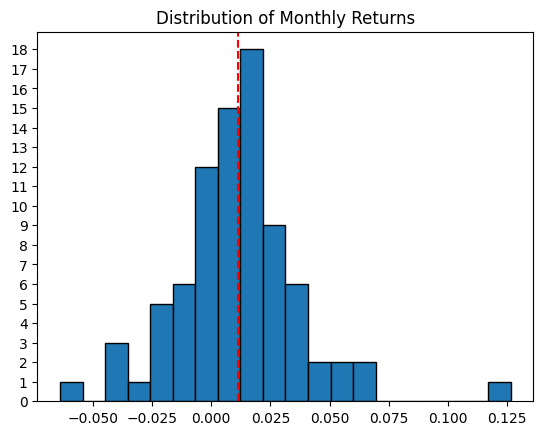

In [32]:
plt.hist(portfolio_returns.values, bins = 20, edgecolor = 'black')
plt.axvline(mean, color = 'r', ls = '--')
plt.yticks(np.linspace(0,18,19))
plt.title('Distribution of Monthly Returns')
plt.savefig('outputs/Distribution of Monthly Returns.png')